# 🩺 PROJE 2 — Sağlık: Kanser Teşhisi (Derinlemesine)
## Mini Proje — Araştırma Projeniz
*Bugün (Gün 2) seçtiğiniz proje — kampın son günü "Bilimsel Yöntem" oturumunda sunulacak*

**Veri seti:** Wisconsin Göğüs Kanseri (569 GERÇEK hasta, 30 ölçüm)
**Kaynak:** UCI ML Repository, University of Wisconsin Hospitals (Wolberg, 1995)

📊 **Bu gerçek hastalardan toplanmış anonim veri** — tıp araştırmalarında binlerce kez kullanıldı.

### 🎯 Sizin Göreviniz
Dün karar ağacı ile %95 aldık. **Bunu daha güvenli ve daha güvenilir yapabilir misiniz?**

**Aşağıdaki seçeneklerden en az 3'ünü deneyin:**
1. **3 farklı model** karşılaştırın (Ağaç, Orman, Lojistik)
2. 🔄 **Cross-validation** ile gerçek performansı ölçün (tek test güvenilir değil!)
3. 📈 **ROC eğrisi:** Sınıflandırma eşiğini değiştirince ne olur?
4. 🎯 **Az öznitelik yetiyor mu?** 30'dan 5'e inip aynı performansı tut
5. 😨 **En güvensiz hastalar:** Model emin değilse o hasta hangileri?
6. ⚖️ **Etik:** False positive vs false negative — hangi tıbbi olarak daha kötü?

---

⚠️ **Hassasiyet uyarısı:** Bu kanser verisi. Aile geçmişin etkilemesinden rahatsızsan eğitmene söyle.

In [2]:
import os
from python_code.helper_tr import *
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

veri = load_breast_cancer(as_frame=True)
X, y = veri.data, veri.target
sinif_adlari = ['kötü huylu', 'iyi huylu']
print(f'✅ {X.shape[0]} hasta, {X.shape[1]} öznitelik')
print(f'Sınıf dağılımı: {dict(y.value_counts())}')


✅ 569 hasta, 30 öznitelik
Sınıf dağılımı: {1: np.int64(357), 0: np.int64(212)}


---
### 👥 Grup Tartışması — Başlamadan Önce
- Bir doktora yardımcı olan yapay zekâ, bir tümörün **iyi mi kötü mü** olduğunu tahmin edecek. Ona güvenmek için en az ne kadar doğru olmalı? %90? %99? %100? Grupça **tek bir sayıda** anlaşmaya çalışın.
- Bu kararı verirken neyi düşündünüz? Bir insan doktor her zaman %100 doğru mu?

## Adım 1: Veri Tanıma + Sınıf Dengesizliği

In [3]:
# Sınıflar arası örnek sayısı dengesi
kotu = (y == 0).sum()
iyi = (y == 1).sum()
print(f'Kötü huylu: {kotu} ({kotu/len(y)*100:.1f}%)')
print(f'İyi huylu : {iyi} ({iyi/len(y)*100:.1f}%)')
print(f'\nBaseline (her şeyi iyi huylu desek): %{iyi/len(y)*100:.1f}')
print('Modelimiz bu değeri MUTLAKA geçmeli!')

Kötü huylu: 212 (37.3%)
İyi huylu : 357 (62.7%)

Baseline (her şeyi iyi huylu desek): %62.7
Modelimiz bu değeri MUTLAKA geçmeli!


📦 Kutu grafiği: mean radius (gruplar: sinif)


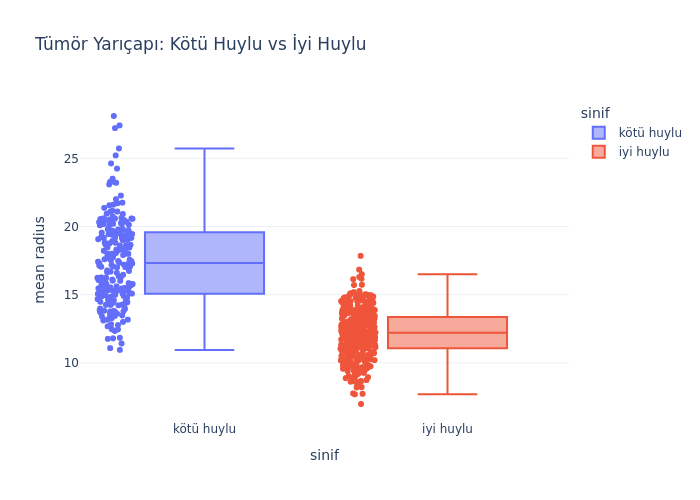

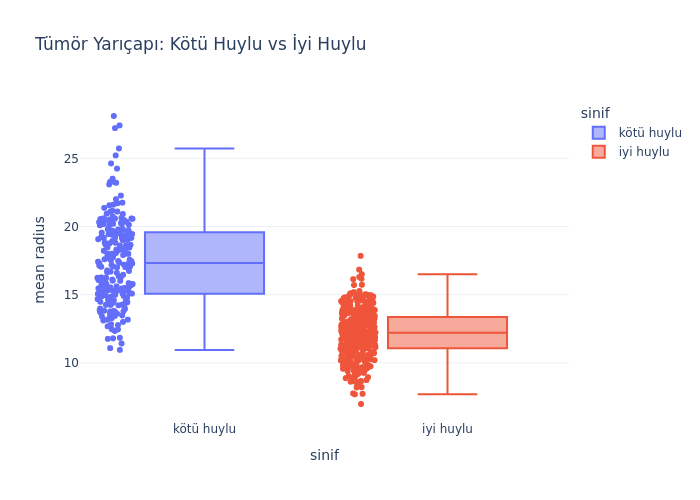

In [4]:
# 2 öznitelik dağılımı sınıflara göre
veri_full = X.copy()
veri_full['sinif'] = y.map({0: 'kötü huylu', 1: 'iyi huylu'})
kutu_grafigi(veri_full, kategori_sutunu='sinif', sayisal_sutun='mean radius',
             baslik='Tümör Yarıçapı: Kötü Huylu vs İyi Huylu')

## Adım 2: 3 Model Karşılaştırması

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_egitim, X_test, y_egitim, y_test = egitim_test_bol(X, y, test_orani=0.2)

# 1. Karar Ağacı
agac = karar_agaci_egit(X_egitim, y_egitim, max_derinlik=3)
agac_d = agac.score(X_test, y_test)

# 2. Rastgele Orman
orman = rastgele_orman_egit(X_egitim, y_egitim)
orman_d = orman.score(X_test, y_test)

# 3. Lojistik Regresyon (ölçeklenmiş)
olc = StandardScaler()
X_e_o = olc.fit_transform(X_egitim)
X_t_o = olc.transform(X_test)
loj = LogisticRegression(max_iter=5000).fit(X_e_o, y_egitim)
loj_d = loj.score(X_t_o, y_test)

print(f'\n📊 Tek-test sonuçları:')
print(f'  Karar Ağacı       : %{agac_d*100:.2f}')
print(f'  Rastgele Orman    : %{orman_d*100:.2f}')
print(f'  Lojistik Regresyon: %{loj_d*100:.2f}')

🪓 Eğitim: 455 örnek | Test: 114 örnek
🌳 Karar ağacı eğitiliyor (max_derinlik=3)...
✅ Eğitim tamamlandı.
🌲🌲🌲 Rastgele orman eğitiliyor (100 ağaç)...
✅ Eğitim tamamlandı.

📊 Tek-test sonuçları:
  Karar Ağacı       : %94.74
  Rastgele Orman    : %96.49
  Lojistik Regresyon: %97.37


---
### 👥 Grup Tartışması
- Üç model de benzer doğruluk verdiyse, hastane hangisini seçmeli — **en doğru** olanı mı, yoksa kararını **açıklayabilen** olanı mı? Neden?
- Bir model 'kötü huylu' dedi ama sebebini söyleyemiyor. Doktor buna güvenmeli mi?

## 🔄 Adım 3: Cross-Validation — Tek Test Yanıltıcı Olabilir!

**Problem:** Tek test verisinde rastlantıyla yüksek doğruluk almış olabiliriz. Gerçek performans için **5-katlı doğrulama**: veriyi 5'e böl, her birini sırayla test yap, ortalamayı al.

In [6]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

agac_cv = cross_val_score(DecisionTreeClassifier(max_depth=3, random_state=42), X, y, cv=5)
orman_cv = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=5)
loj_cv = cross_val_score(
    Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=5000))]),
    X, y, cv=5,
)

print(f'📊 5-katlı cross-validation sonuçları:')
print(f'  Karar Ağacı       : %{agac_cv.mean()*100:.2f} ± {agac_cv.std()*100:.2f}')
print(f'  Rastgele Orman    : %{orman_cv.mean()*100:.2f} ± {orman_cv.std()*100:.2f}')
print(f'  Lojistik Regresyon: %{loj_cv.mean()*100:.2f} ± {loj_cv.std()*100:.2f}')
print(f'\n💡 ± simgesi standart sapma. Düşük = daha kararlı model')

📊 5-katlı cross-validation sonuçları:
  Karar Ağacı       : %91.91 ± 2.46
  Rastgele Orman    : %95.61 ± 2.28
  Lojistik Regresyon: %98.07 ± 0.65

💡 ± simgesi standart sapma. Düşük = daha kararlı model


**Görev:** Cross-validation sonuçları tek-test sonuçlarından farklı mı? Hangi model en kararlı (en düşük std)?

## 📈 Adım 4: ROC Eğrisi — Sınıflandırma Eşiği Etkisi

Modeller normalde 0.5 eşiği kullanır (>0.5 → iyi huylu). Ama tıpta:
- Eşiği 0.7'ye çıkarsak → "iyi huylu" demek için daha emin olur (false negative azalır, kanseri kaçırma azalır) ✅
- Eşiği 0.3'e indirsek → daha çok "iyi huylu" der (false positive artar)

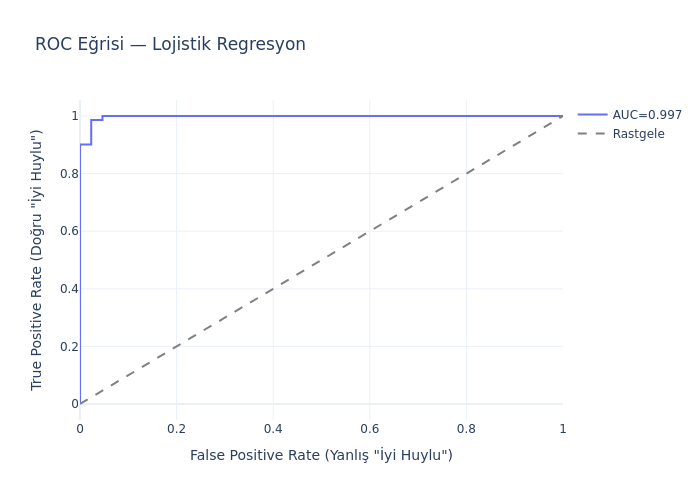

AUC (Area Under Curve): 0.997
  1.0 = mükemmel, 0.5 = rastgele


In [7]:
from sklearn.metrics import roc_curve, auc
import plotly.graph_objects as go

# Lojistik regresyonun olasılık tahminleri
olas = loj.predict_proba(X_t_o)[:, 1]
fpr, tpr, esikler = roc_curve(y_test, olas)
auc_skor = auc(fpr, tpr)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'AUC={auc_skor:.3f}'))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Rastgele',
                          line=dict(dash='dash', color='gray')))
fig.update_layout(title='ROC Eğrisi — Lojistik Regresyon',
                  xaxis_title='False Positive Rate (Yanlış "İyi Huylu")',
                  yaxis_title='True Positive Rate (Doğru "İyi Huylu")')
fig.show()
print(f'AUC (Area Under Curve): {auc_skor:.3f}')
print(f'  1.0 = mükemmel, 0.5 = rastgele')

**Görev:** AUC kaç? Bu modelin "hangi eşikte olursa olsun" iyi olduğunu gösterir.

## 🎯 Adım 5: Az Öznitelik Yetiyor mu?

30 öznitelik ölçmek pahalı. Sadece **en önemli 5** ile aynı sonucu alabiliyor muyuz?

In [8]:
onem_df = pd.DataFrame({'oz': X.columns, 'imp': orman.feature_importances_}).sort_values('imp', ascending=False)
print('En önemli 10 öznitelik:')
print(onem_df.head(10).to_string(index=False))

En önemli 10 öznitelik:
                  oz      imp
          worst area 0.153892
worst concave points 0.144663
 mean concave points 0.106210
        worst radius 0.077987
      mean concavity 0.068001
     worst perimeter 0.067115
      mean perimeter 0.053270
         mean radius 0.048703
           mean area 0.047555
     worst concavity 0.031802


In [9]:
# Farklı sayıda öznitelikle performans
sonuclar = []
for n in [3, 5, 10, 20, 30]:
    en_iyi_n = onem_df['oz'].head(n).tolist()
    cv = cross_val_score(
        RandomForestClassifier(n_estimators=100, random_state=42),
        X[en_iyi_n], y, cv=5
    )
    sonuclar.append({'oznitelik_sayisi': n, 'doğruluk': cv.mean(), 'std': cv.std()})
    print(f'{n:2} öznitelik: %{cv.mean()*100:.2f} ± {cv.std()*100:.2f}')

 3 öznitelik: %93.85 ± 2.00


 5 öznitelik: %94.73 ± 2.66


10 öznitelik: %94.73 ± 3.09


20 öznitelik: %96.49 ± 2.54


30 öznitelik: %95.96 ± 2.26


**Görev:** 30 yerine 5 öznitelik %____ performans veriyor. Tıbbi maliyet/fayda — 25 ölçümden vazgeçmek değer mi?

---
### 👥 Grup Tartışması
- 5 test, 30 testin işini büyük ölçüde görüyorsa hastadan hangi testleri isteriz? **Az test** = daha ucuz, hızlı, hastayı yormaz; ama biraz daha risk. Grupça bir karar verin.
- Maliyet ile doğruluk arasında seçim yapmak adil mi? Bu kararı kim vermeli?

## 😨 Adım 6: En Güvensiz Hastalar

Model %92 olasılıkla "iyi huylu" derse — emin. Ama %52 derse — şüpheli! Bu hastalara doktor tekrar bakmalı.

In [10]:
olasiliklar = orman.predict_proba(X_test)
guvensizlik = np.abs(olasiliklar[:, 1] - 0.5)

test_df = X_test.copy()
test_df['gercek'] = y_test.values
test_df['olasilik_iyi'] = olasiliklar[:, 1]
test_df['guvensizlik'] = guvensizlik

en_guvensiz = test_df.sort_values('guvensizlik').head(5)
print('🤔 Modelin en az emin olduğu 5 hasta:')
print(en_guvensiz[['mean radius', 'mean texture', 'olasilik_iyi', 'gercek']].to_string())
print('\nBu hastaları manuel doktor değerlendirmesine yönlendirmek kritik!')

🤔 Modelin en az emin olduğu 5 hasta:
     mean radius  mean texture  olasilik_iyi  gercek
148        14.44         15.18          0.58       1
81         13.34         15.86          0.35       1
255        13.96         17.05          0.71       0
238        14.22         27.85          0.71       1
39         13.48         20.82          0.29       0

Bu hastaları manuel doktor değerlendirmesine yönlendirmek kritik!


## ⚖️ Adım 7: Etik — Hata Maliyeti

In [11]:
from sklearn.metrics import confusion_matrix
tahminler = orman.predict(X_test)
cm = confusion_matrix(y_test, tahminler)
print('Karmaşıklık Matrisi:')
print(f'                  Tahmin: Kötü   Tahmin: İyi')
print(f'Gerçek: Kötü      {cm[0][0]:5}          {cm[0][1]:5}  ← FALSE NEGATIVE (kanseri kaçırdık!) ☠️')
print(f'Gerçek: İyi       {cm[1][0]:5}          {cm[1][1]:5}  ← FALSE POSITIVE (yanlış endişe)')
print(f'\nFalse Negative sayısı: {cm[0][1]} (TIBBI OLARAK CIDDI)')
print(f'False Positive sayısı: {cm[1][0]} (sadece extra test gerek)')

Karmaşıklık Matrisi:
                  Tahmin: Kötü   Tahmin: İyi
Gerçek: Kötü         40              3  ← FALSE NEGATIVE (kanseri kaçırdık!) ☠️
Gerçek: İyi           1             70  ← FALSE POSITIVE (yanlış endişe)

False Negative sayısı: 3 (TIBBI OLARAK CIDDI)
False Positive sayısı: 1 (sadece extra test gerek)


**Tartışma:** Tıbbi sistemde False Negative ölümcül olabilir. False Positive ekstra biyopsi maliyeti. **Eşik 0.5 yerine 0.3 yaparsak**, daha çok "iyi huylu" deriz ve FN azalır ama FP artar. Bu hayat-maliyet dengesi tartışılır.

---
### 👥 Grup Tartışması — Sunuma Hazırlık
- Bir ekip olarak: Bu modeli gerçek bir hastanede **kullanır mıydınız**? Evet/hayır ve **bir koşul** belirleyin (örn. 'sadece doktorla birlikte').
- Sunumda hangi **tek grafiği** gösterseniz dinleyici sizi en iyi anlar?

## Adım 8: Sunum için notlarınız

- Sınıf dengesi: %___ kötü, %___ iyi (baseline %___)
- 3 model CV ortalama: Ağaç %___, Orman %___, Lojistik %___
- En kararlı model (en düşük std): _________________
- ROC AUC: ___ (1.0 mükemmel)
- 5 öznitelikle performans: %___ vs 30 öznitelikle %___
- En güvensiz hasta sayısı (olasılık 0.4-0.6): ___
- False Negative sayısı: ___ (kritik!)
- **Etik sonuç:** Bu modeli tek başına hastane karar verebilir mi?

📝 Bilimsel yöntem şablonunu doldurun!

---
## 🚀 Hızlı Bitirenler İçin BONUS

1. **Hyperparameter tuning:** `GridSearchCV` ile orman için en iyi `n_estimators`+`max_depth` bulun
2. **Feature engineering:** `texture/radius` gibi yeni özellikler türetin — model daha iyi mi?
3. **Ensemble:** `VotingClassifier` ile 3 modeli birleştirip oy çoğunluğu alın
4. **Calibration:** Modelin söylediği olasılık gerçek mi? `CalibrationDisplay` deneyin
5. **SHAP değerleri:** Her tahmin için hangi öznitelik ne kadar katkıda bulundu? (gelişmiş açıklama)

## 🆘 Yardım — Sık Karşılaşılan Hatalar

**❌ Lojistik regresyon yakınsamıyor** → `LogisticRegression(max_iter=5000)` veya `StandardScaler` kullanın

**❌ CV uzun sürüyor** → 569 hasta × 5-fold normalde 5-10 saniye. Daha uzunsa, n_estimators'ı düşürün

**❌ ROC eğrisi düz çizgi (köşegen)** → Modelin olasılıkları tek bir değer veriyor. `predict_proba` çağırdınız mı, `predict` değil?

**❌ Confusion matrix beklenmedik** → Sınıf etiketleri 0=kötü, 1=iyi. Çıktıyı doğru yorumlayın

**❌ Doğruluk %100** → Veri sızıntısı. y'yi X'ten yanlışlıkla aldınız mı?

---
# 🧑‍🏫 Öğretmen Rehberi & Cevap Anahtarı
*Bu bölüm öğretmen içindir: beklenen sonuçlar, sık takılma noktaları ve tartışma soruları. Öğrenciler projeyi yaptıktan sonra bakabilir.*

# 🎓 PROJE 1 EĞİTMEN — Sağlık (Wisconsin Göğüs Kanseri)
## Mini Proje Saha Rehberi

**Bu notebook eğitmenler içindir.** Öğrenci paylaşılmaz.

---

## 🚨 Önemli Hassasiyet Notu

Bu projeyi seçen grupla **proje çalışması başlamadan ÖNCE** kısa bir konuşma yapın:

> "Bu, gerçek hastalardan toplanmış anonim bir veri seti. Doktorlara yardımcı olmak için bu tür modeller geliştirilir. Ailenizde benzer bir durum varsa ve bu konu rahatsız edici geliyorsa, başka bir projeye geçebilirsiniz — sorun değil."

---

## 👥 Bu Projeyi Kim Seçer?
- Tıp/biyoloji ilgisi olan, ileride sağlık alanı düşünen öğrenciler
- Dünkü Wisconsin demosunu beğenmiş gruplar
- "Ciddi konular" sevenler

## 🎯 Beklenen Çıktı (2 saat sonunda)
- En az 2 model karşılaştırılmış (karar ağacı + 1 başkası)
- Doğruluk tablosu hazırlanmış
- Karmaşıklık matrisi yorumlanmış (FN vs FP tartışması)
- En önemli 3 öznitelik tanımlanmış

## 📊 Beklenen Sayısal Sonuçlar
| Model | Doğruluk |
|-------|----------|
| Karar Ağacı (derinlik 3) | ~%93-95 |
| Rastgele Orman (100 ağaç) | ~%96-97 |
| Lojistik Regresyon | ~%97 |
| Orman (sadece 5 öznitelik) | ~%94-96 |

## ⚠️ Tipik Takılma Noktaları

**1. Lojistik regresyonun ölçekleme gereksinimi**
Öğrenciler `LogisticRegression()` çağırır, `max_iter` warning'i alır. Sonra ne yapacaklarını bilmezler.
→ "`StandardScaler` ile veriyi merkezleyin" deyin. Hızlı bir benzetme: "30 öznitelikte biri 0-1, biri 0-1000 — model kafası karışıyor"

**2. "Doğruluk %100" gibi tuhaf sonuçlar**
→ Genelde test verisi yanlış oluşturulmuş. `egitim_test_bol(...)` çağırdılar mı?

**3. "En önemli özniteliği bulamıyorum" — lojistik regresyonda**
→ Lojistikte `feature_importances_` yok. `.coef_[0]` kullanılır. Bunu açıklayın

**4. Karar ağacı çizimi okunaksız**
→ Derinliği 3-4'te tutsunlar. 7-8 derinlikte ağaç görsel olarak çekilemez

## 🎯 Derinleştirme Soruları (eğer hızlı bitirirlerse)

1. "Modelin yanlış tahmin ettiği 5 hastayı bulun. Bu hastaların değerleri ortalamadan ne kadar farklı?" (`model.predict_proba` ile en güvensiz tahminleri)
2. "Eğitim/test oranını %50/%50 yapın. Doğruluk düştü mü?" (Az veriyle eğitim ne kadar zorlanır)
3. "`mean radius` özniteliğini çıkarın ve modeli tekrar eğitin. Doğruluk ne kadar düştü?"

## 💭 Etik Tartışma — Bu Projenin Kalbi

Bu grupla mutlaka 5-10 dakikalık etik tartışma yapın. Açılış sorusu:

> "Modeliniz %95 doğru. 1000 hastadan 50'sinde yanılır. Hastane bu modeli **doktor olmadan** kullansa, ne olur?"

Yönlendirme noktaları:
- FN (kanseri kaçırdık) ölümcül → bu yüzden modeller doktora yardımcı, doktor yerine değil
- Veri 1990'larda ABD'de toplandı — Türkiye'de aynı çalışır mı?
- Eğitim verisi sadece bu şehir/etnik grubu içeriyorsa, başkalarında çalışır mı? ("algoritmik adalet")

## 🎤 Sunum Koçluğu

Sunumlarında şunlar olsun:
- En az 1 grafik (karmaşıklık matrisi tercihen)
- 3 model karşılaştırma tablosu
- **Etik soru cevaplı** — "bunu bir doktor neden tek başına kullanmaz?"